# Lateral Variability Comparison: Area A vs Area B
### Five petrophysical properties · Five comparison methods

| Property | Area A range | Area B range |
|----------|-------------|-------------|
| Structure | 7,500 – 10,000 ft | 7,800 – 9,800 ft |
| Porosity | 0.05 – 0.10 | 0.06 – 0.14 |
| Isopach | 20 – 60 ft | 20 – 60 ft |
| Water saturation | 0.20 – 0.60 | 0.15 – 0.55 |
| Gamma ray | 30 – 120 API | 25 – 130 API |

**Comparison methods covered:**
1. Coefficient of Variation (CV) — normalized heterogeneity score
2. Variogram range comparison — spatial correlation length
3. PCA complexity index — number of modes needed to explain 90% variance
4. Spatial cross-variogram — inter-property co-variation vs distance
5. Information entropy maps — local unpredictability & risk mapping


## 0. Setup & grid generation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.optimize import curve_fit
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy as scipy_entropy
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})

GRID = 80
AREAS = ['Area A', 'Area B']
PROPS = ['Structure', 'Porosity', 'Isopach', 'Sw', 'GR']
UNITS = {'Structure':'ft', 'Porosity':'frac', 'Isopach':'ft', 'Sw':'frac', 'GR':'API'}
CMAPS = {'Structure':'RdYlGn_r','Porosity':'Blues','Isopach':'YlOrBr','Sw':'RdBu_r','GR':'Purples'}
COLORS = {'Area A': '#185FA5', 'Area B': '#993C1D'}  # blue vs coral


In [2]:
# ── Area A base field (same as interactive maps) ──────────────────────────────
def bf_A(nx, ny):
    return (
        0.42*np.sin(nx*np.pi*1.2+0.3)*np.cos(ny*np.pi*0.9+0.5) +
        0.28*np.sin(nx*np.pi*2.1+1.1)*np.sin(ny*np.pi*1.7+0.8) +
        0.18*np.cos(nx*np.pi*3.0+0.7)*np.cos(ny*np.pi*2.5+1.3) +
        0.08*np.sin(nx*np.pi*4.0+2.0)*np.cos(ny*np.pi*3.8+0.4) +
        0.14*(1-np.exp(-((nx-0.30)**2+(ny-0.25)**2)/0.015)) -
        0.11*np.exp(-((nx-0.72)**2+(ny-0.68)**2)/0.012)
    )

# ── Area B base field (higher frequency, patchier character) ───────────────────
def bf_B(nx, ny):
    return (
        0.35*np.sin(nx*np.pi*2.5+0.8)*np.cos(ny*np.pi*1.8+1.2) +
        0.22*np.cos(nx*np.pi*4.2+0.4)*np.sin(ny*np.pi*3.1+0.7) +
        0.28*np.sin(nx*np.pi*1.1+1.5)*np.cos(ny*np.pi*2.4+0.3) +
        0.15*np.cos(nx*np.pi*5.5+2.1)*np.cos(ny*np.pi*4.0+1.8) +
        0.18*np.exp(-((nx-0.55)**2+(ny-0.40)**2)/0.018) -
        0.14*np.exp(-((nx-0.22)**2+(ny-0.75)**2)/0.010) -
        0.10*np.exp(-((nx-0.78)**2+(ny-0.20)**2)/0.013)
    )

x = np.linspace(0, 1, GRID+1)
NX, NY = np.meshgrid(x, x)
BF_A = bf_A(NX, NY)
BF_B = bf_B(NX, NY)

def clip(arr, lo, hi): return np.clip(arr, lo, hi)

grids = {
    'Area A': {
        'Structure': clip(7500+900*np.sin(NX*np.pi*1.2+0.3)*np.cos(NY*np.pi*0.9+0.5)
                          +600*np.sin(NX*np.pi*2.1+1.1)*np.sin(NY*np.pi*1.7+0.8)
                          +400*np.cos(NX*np.pi*3.0+0.7)*np.cos(NY*np.pi*2.5+1.3)
                          +200*np.sin(NX*np.pi*4.0+2.0)*np.cos(NY*np.pi*3.8+0.4)
                          +300*(1-np.exp(-((NX-0.30)**2+(NY-0.25)**2)/0.015))
                          -250*np.exp(-((NX-0.72)**2+(NY-0.68)**2)/0.012), 7500, 10000),
        'Porosity': clip(0.075+0.025*BF_A, 0.05, 0.10),
        'Isopach':  clip(40+20*(-BF_A*0.9+0.05*np.sin(NX*5)*np.cos(NY*4)), 20, 60),
        'Sw':       clip(0.40-0.18*BF_A+0.04*np.cos(NX*6+NY*4), 0.20, 0.60),
        'GR':       clip(75+42*(BF_A*0.8+0.12*np.sin(NX*7+1)*np.sin(NY*5+0.5)), 30, 120),
    },
    'Area B': {
        'Structure': clip(8800+600*np.sin(NX*np.pi*2.5+0.8)*np.cos(NY*np.pi*1.8+1.2)
                          +400*np.cos(NX*np.pi*4.2+0.4)*np.sin(NY*np.pi*3.1+0.7)
                          +300*np.exp(-((NX-0.55)**2+(NY-0.40)**2)/0.018)
                          -200*np.exp(-((NX-0.22)**2+(NY-0.75)**2)/0.010), 7800, 9800),
        'Porosity': clip(0.10+0.04*BF_B+0.008*np.cos(NX*8)*np.sin(NY*6), 0.06, 0.14),
        'Isopach':  clip(40+18*(BF_B*0.7+0.15*np.sin(NX*9+1)*np.cos(NY*7+2)), 20, 60),
        'Sw':       clip(0.35-0.16*BF_B+0.06*np.sin(NX*7+NY*5+0.5)+0.03*np.cos(NX*11), 0.15, 0.55),
        'GR':       clip(78+48*(BF_B*0.6+0.20*np.sin(NX*10+2)*np.cos(NY*8+1)+0.08*np.sin(NX*15)), 25, 130),
    }
}

print("Grids ready:")
for area, props in grids.items():
    print(f"  {area}:", {p: f"{g.min():.3g}–{g.max():.3g}" for p,g in props.items()})


Grids ready:
  Area A: {'Structure': '7.5e+03–8.98e+03', 'Porosity': '0.0648–0.092', 'Isopach': '28.4–46.6', 'Sw': '0.248–0.467', 'GR': '58–102'}
  Area B: {'Structure': '7.84e+03–9.64e+03', 'Porosity': '0.0719–0.131', 'Isopach': '28.8–49.4', 'Sw': '0.224–0.55', 'GR': '49–103'}


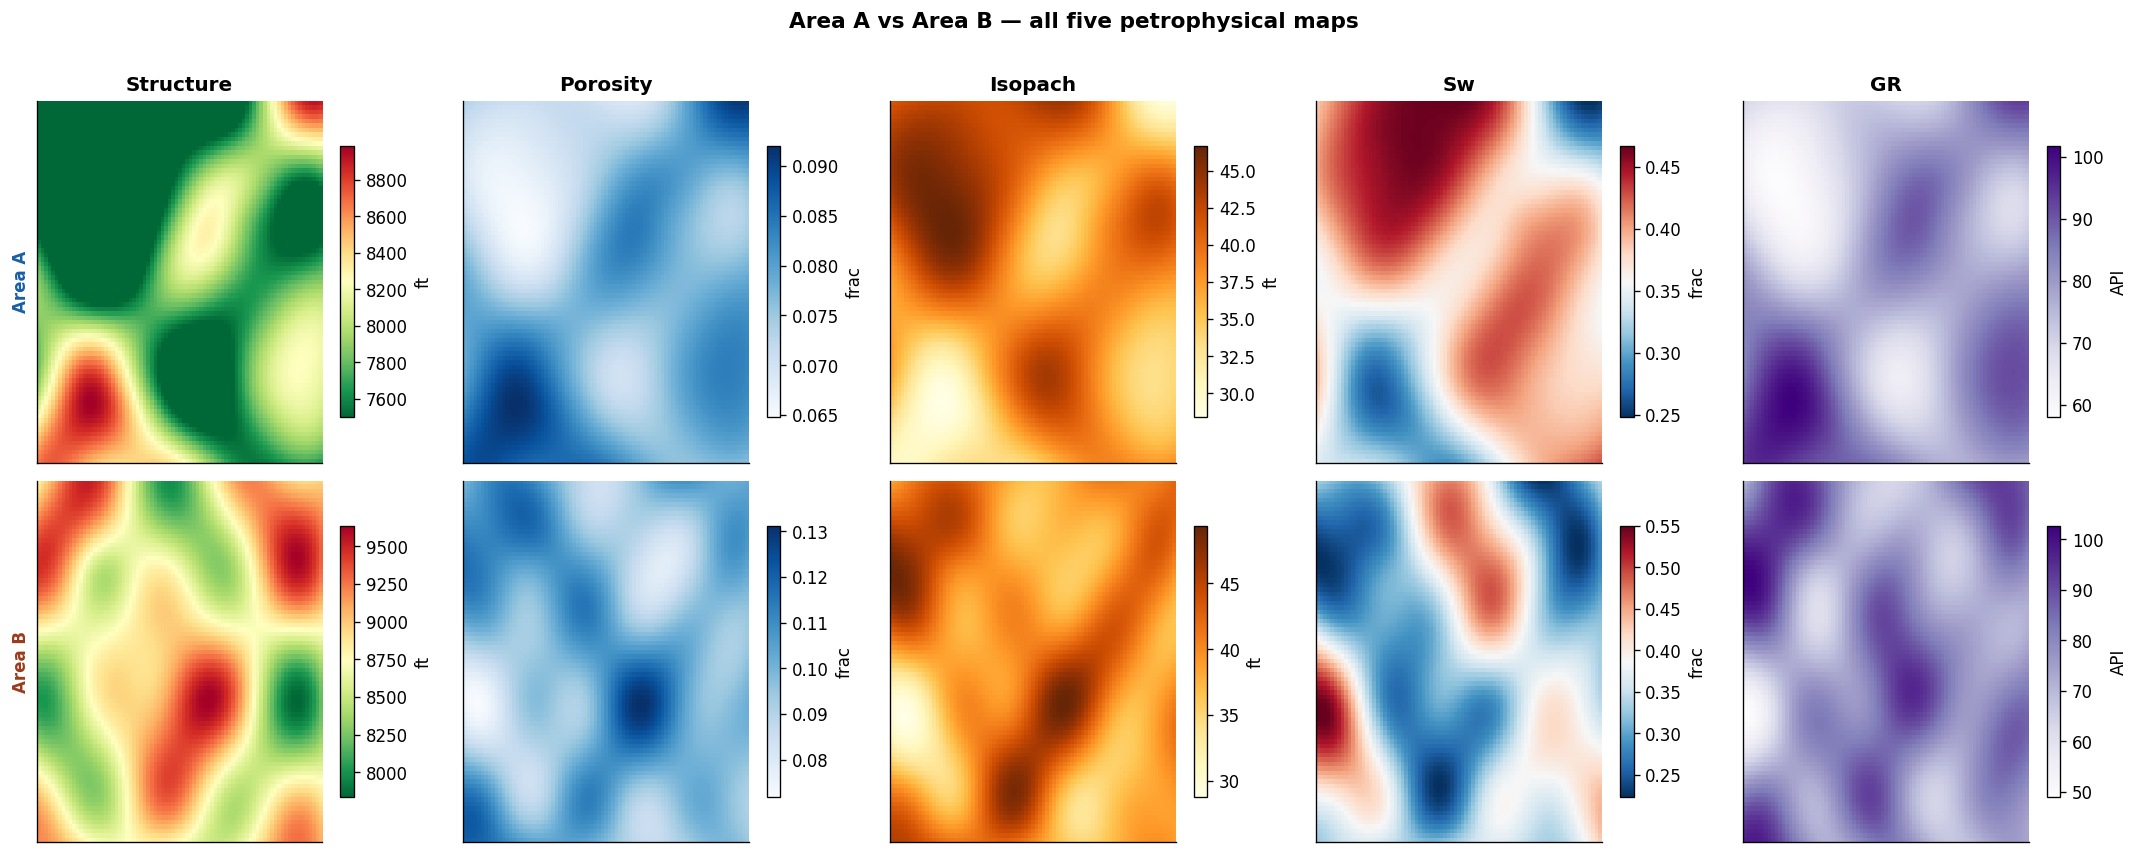

In [3]:
# ── Side-by-side overview of all maps ─────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row, area in enumerate(AREAS):
    for col, prop in enumerate(PROPS):
        ax = axes[row, col]
        g  = grids[area][prop]
        im = ax.imshow(g, origin='lower', cmap=CMAPS[prop],
                       extent=[0,1,0,1], aspect='auto')
        plt.colorbar(im, ax=ax, shrink=0.75, label=UNITS[prop])
        if row == 0: ax.set_title(prop, fontweight='bold')
        if col == 0: ax.set_ylabel(area, fontweight='bold', color=COLORS[area])
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Area A vs Area B — all five petrophysical maps', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('00_overview_both_areas.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Method 1 — Coefficient of Variation (CV)

CV = σ / |μ| is a unit-free heterogeneity score directly comparable across properties and areas.
A higher CV indicates greater lateral variability relative to the local mean.


In [4]:
# ── Compute CV for every property in every area ───────────────────────────────
cv_data = {}
for area in AREAS:
    cv_data[area] = {}
    for prop in PROPS:
        g = grids[area][prop].ravel()
        cv_data[area][prop] = g.std() / np.abs(g.mean())

cv_df = pd.DataFrame(cv_data).T
cv_df.index.name = 'Area'
print("Coefficient of Variation table:")
print(cv_df.round(4).to_string())


Coefficient of Variation table:
        Structure  Porosity  Isopach      Sw      GR
Area                                                
Area A     0.0484    0.0801   0.1097  0.1254  0.1278
Area B     0.0447    0.1062   0.0962  0.2050  0.1185


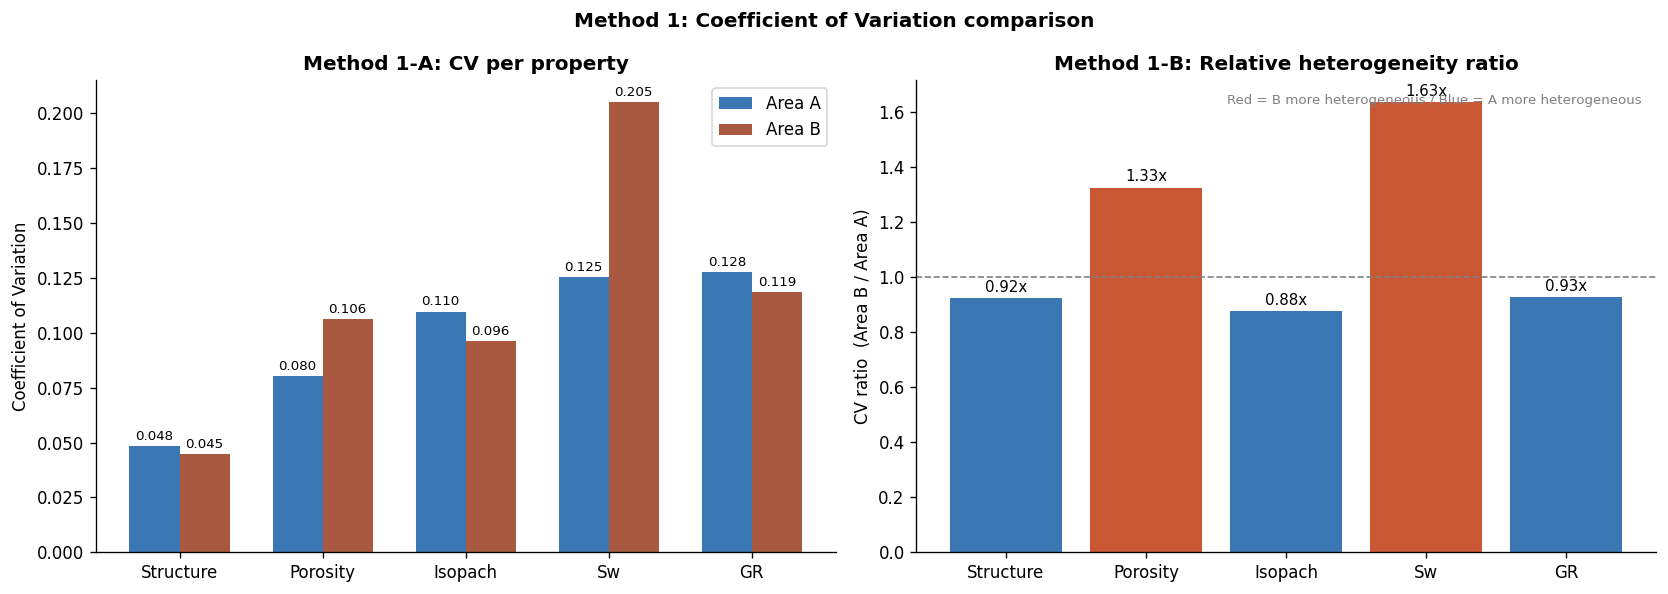

In [5]:
# ── Grouped bar chart ─────────────────────────────────────────────────────────
x_pos = np.arange(len(PROPS))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bars_A = ax.bar(x_pos - width/2, cv_df.loc["Area A"], width,
                label="Area A", color=COLORS["Area A"], alpha=0.85)
bars_B = ax.bar(x_pos + width/2, cv_df.loc["Area B"], width,
                label="Area B", color=COLORS["Area B"], alpha=0.85)
ax.bar_label(bars_A, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(bars_B, fmt="%.3f", padding=2, fontsize=8)
ax.set_xticks(x_pos); ax.set_xticklabels(PROPS)
ax.set_ylabel("Coefficient of Variation")
ax.set_title("Method 1-A: CV per property", fontweight="bold")
ax.legend()

ax2 = axes[1]
ratio = cv_df.loc["Area B"] / cv_df.loc["Area A"]
colors_bar = ["#c03a10" if r > 1 else "#185FA5" for r in ratio]
bars = ax2.bar(PROPS, ratio, color=colors_bar, alpha=0.85)
ax2.bar_label(bars, fmt="%.2fx", padding=2, fontsize=9)
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("CV ratio  (Area B / Area A)")
ax2.set_title("Method 1-B: Relative heterogeneity ratio", fontweight="bold")
ax2.text(0.98, 0.97, "Red = B more heterogeneous / Blue = A more heterogeneous",
         transform=ax2.transAxes, ha="right", va="top", fontsize=8, color="gray")

plt.suptitle("Method 1: Coefficient of Variation comparison", fontweight="bold")
plt.tight_layout()
plt.savefig("01_cv_comparison.png", dpi=130, bbox_inches="tight")
plt.show()


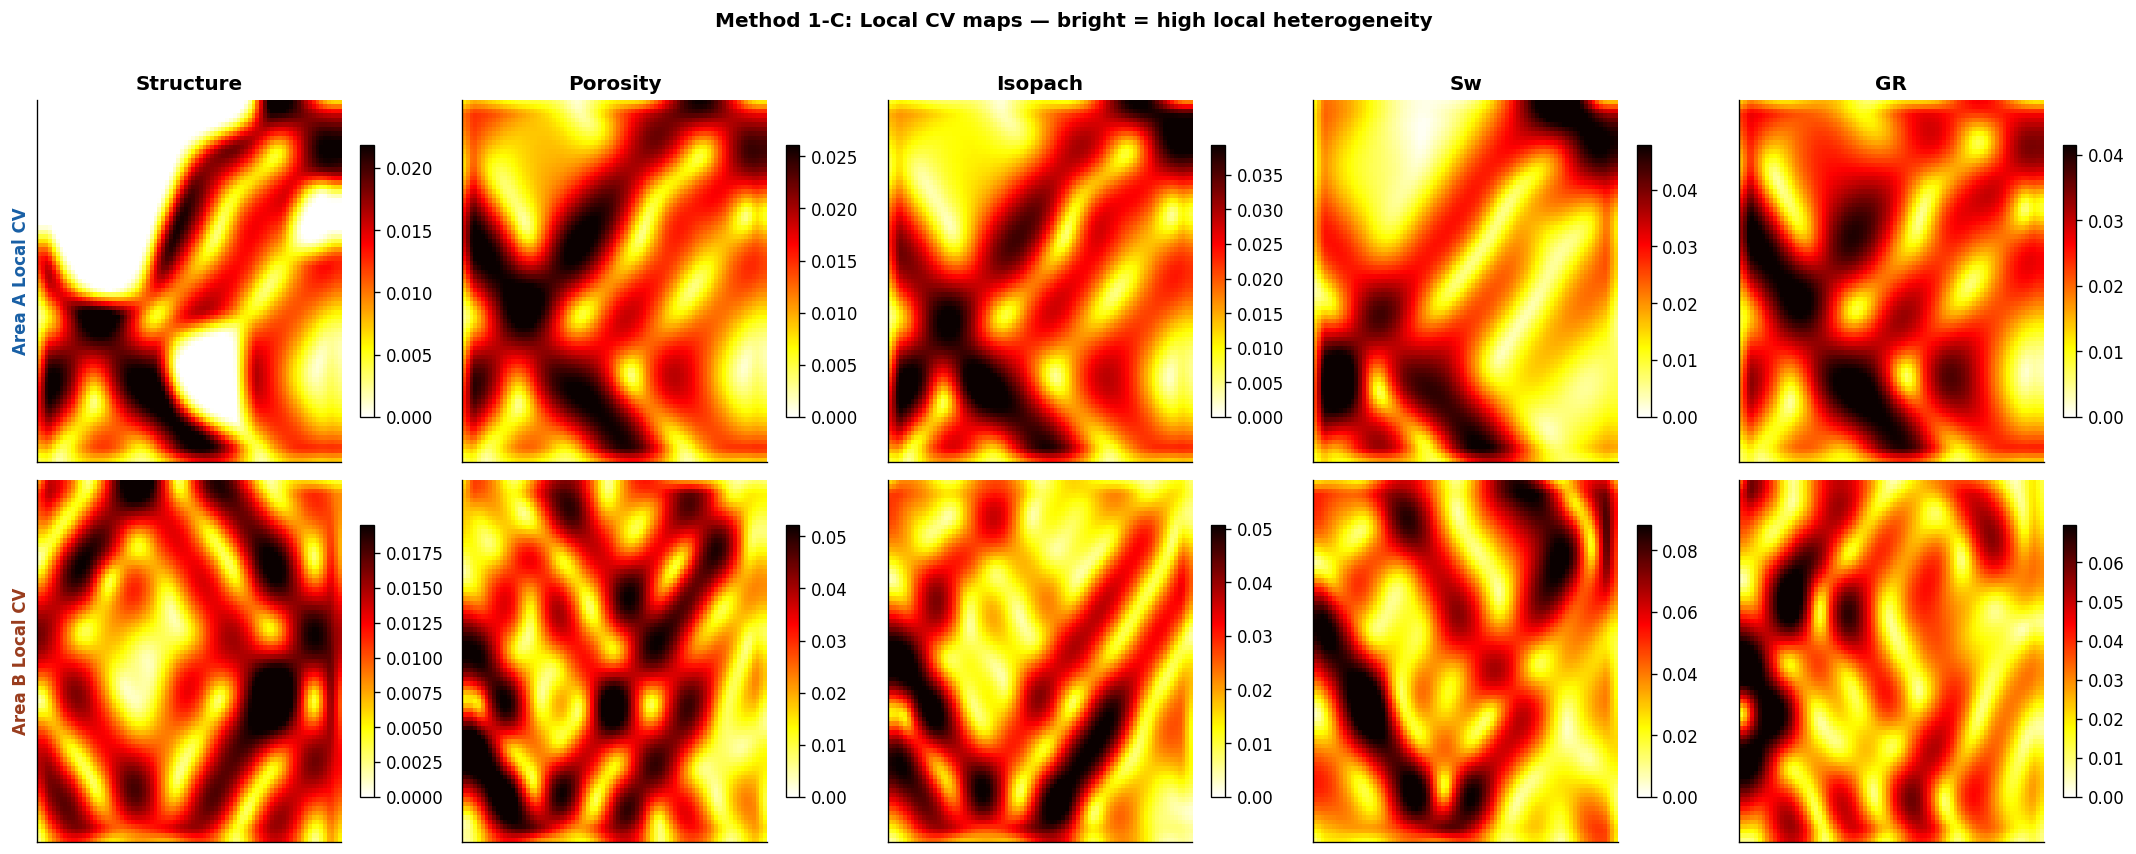

In [6]:
# ── CV spatial maps (local CV via moving window) ──────────────────────────────
from scipy.ndimage import uniform_filter

def local_cv(grid, size=7):
    lm = uniform_filter(grid.astype(float), size=size)
    ls = np.sqrt(np.maximum(uniform_filter(grid**2, size=size) - lm**2, 0))
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(lm != 0, ls / np.abs(lm), 0)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row, area in enumerate(AREAS):
    for col, prop in enumerate(PROPS):
        ax = axes[row, col]
        lcv = local_cv(grids[area][prop])
        vmax = np.percentile(lcv, 97)
        im = ax.imshow(lcv, origin="lower", cmap="hot_r",
                       vmin=0, vmax=vmax, extent=[0,1,0,1], aspect="auto")
        plt.colorbar(im, ax=ax, shrink=0.75)
        if row == 0: ax.set_title(prop, fontweight="bold")
        if col == 0: ax.set_ylabel(area + " Local CV", fontweight="bold", color=COLORS[area])
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Method 1-C: Local CV maps — bright = high local heterogeneity",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("01c_local_cv_maps.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Method 2 — Variogram range comparison

The variogram range is the lag distance at which spatial correlation vanishes.
- Short range → property changes rapidly over space (patchy heterogeneity)
- Long range → gradual, laterally continuous variation

We fit spherical models: γ(h) = nugget + (sill−nugget)·[1.5(h/a) − 0.5(h/a)³] for h ≤ a, else sill.


In [7]:
def experimental_variogram(grid, n_lags=20, max_lag_frac=0.45, n_sample=2000):
    flat = grid.ravel()
    rng  = np.random.default_rng(42)
    idx  = rng.choice(len(flat), size=min(n_sample, len(flat)), replace=False)
    r_i, c_i = np.unravel_index(idx, grid.shape)
    coords = np.stack([r_i, c_i], axis=1).astype(float)
    vals   = flat[idx]
    dists  = squareform(pdist(coords))
    max_d  = dists.max() * max_lag_frac
    lags   = np.linspace(0, max_d, n_lags+1)
    gamma, counts = [], []
    for lo, hi in zip(lags[:-1], lags[1:]):
        mask = (dists > lo) & (dists <= hi)
        if mask.sum() < 5:
            gamma.append(np.nan); counts.append(0); continue
        ii, jj = np.where(mask)
        gamma.append(0.5 * np.mean((vals[ii]-vals[jj])**2))
        counts.append(mask.sum())
    centers = (lags[:-1]+lags[1:])/2
    return centers, np.array(gamma), np.array(counts)

def spherical(h, nugget, sill, rang):
    h = np.asarray(h, float)
    return np.where(h <= rang,
                    nugget+(sill-nugget)*(1.5*(h/rang)-0.5*(h/rang)**3),
                    sill)

vario_results = {}   # {area: {prop: {nugget, sill, range, h, gamma}}}
for area in AREAS:
    vario_results[area] = {}
    for prop in PROPS:
        h, gamma, cnt = experimental_variogram(grids[area][prop])
        valid = ~np.isnan(gamma)
        try:
            p0 = [gamma[valid].min()*0.1, gamma[valid].max(), h[valid].max()*0.5]
            popt, _ = curve_fit(spherical, h[valid], gamma[valid], p0=p0,
                                maxfev=8000, bounds=([0,0,1],[np.inf,np.inf,np.inf]))
            vario_results[area][prop] = dict(nugget=popt[0], sill=popt[1],
                                             range=popt[2], h=h, gamma=gamma,
                                             valid=valid, popt=popt, fitted=True)
        except Exception:
            vario_results[area][prop] = dict(nugget=np.nan, sill=np.nan,
                                             range=np.nan, h=h, gamma=gamma,
                                             valid=valid, popt=None, fitted=False)

print("Variogram parameters:")
rows = []
for area in AREAS:
    for prop in PROPS:
        r = vario_results[area][prop]
        rows.append({'Area':area,'Property':prop,
                     'Nugget':round(r['nugget'],5),
                     'Sill':round(r['sill'],5),
                     'Range (cells)':round(r['range'],2)})
vario_df = pd.DataFrame(rows).set_index(['Area','Property'])
print(vario_df.to_string())


Variogram parameters:
                  Nugget          Sill  Range (cells)
Area   Property                                      
Area A Structure     0.0  139406.88775          38.05
       Porosity      0.0       0.00004          24.51
       Isopach       0.0      17.97173          43.81
       Sw            0.0       0.00571         138.47
       GR            0.0     108.28497          45.24
Area B Structure     0.0  185891.05838          33.29
       Porosity      0.0       0.00014          31.56
       Isopach       0.0      17.90089          32.81
       Sw            0.0       0.00646          37.89
       GR            0.0      91.37547          26.53


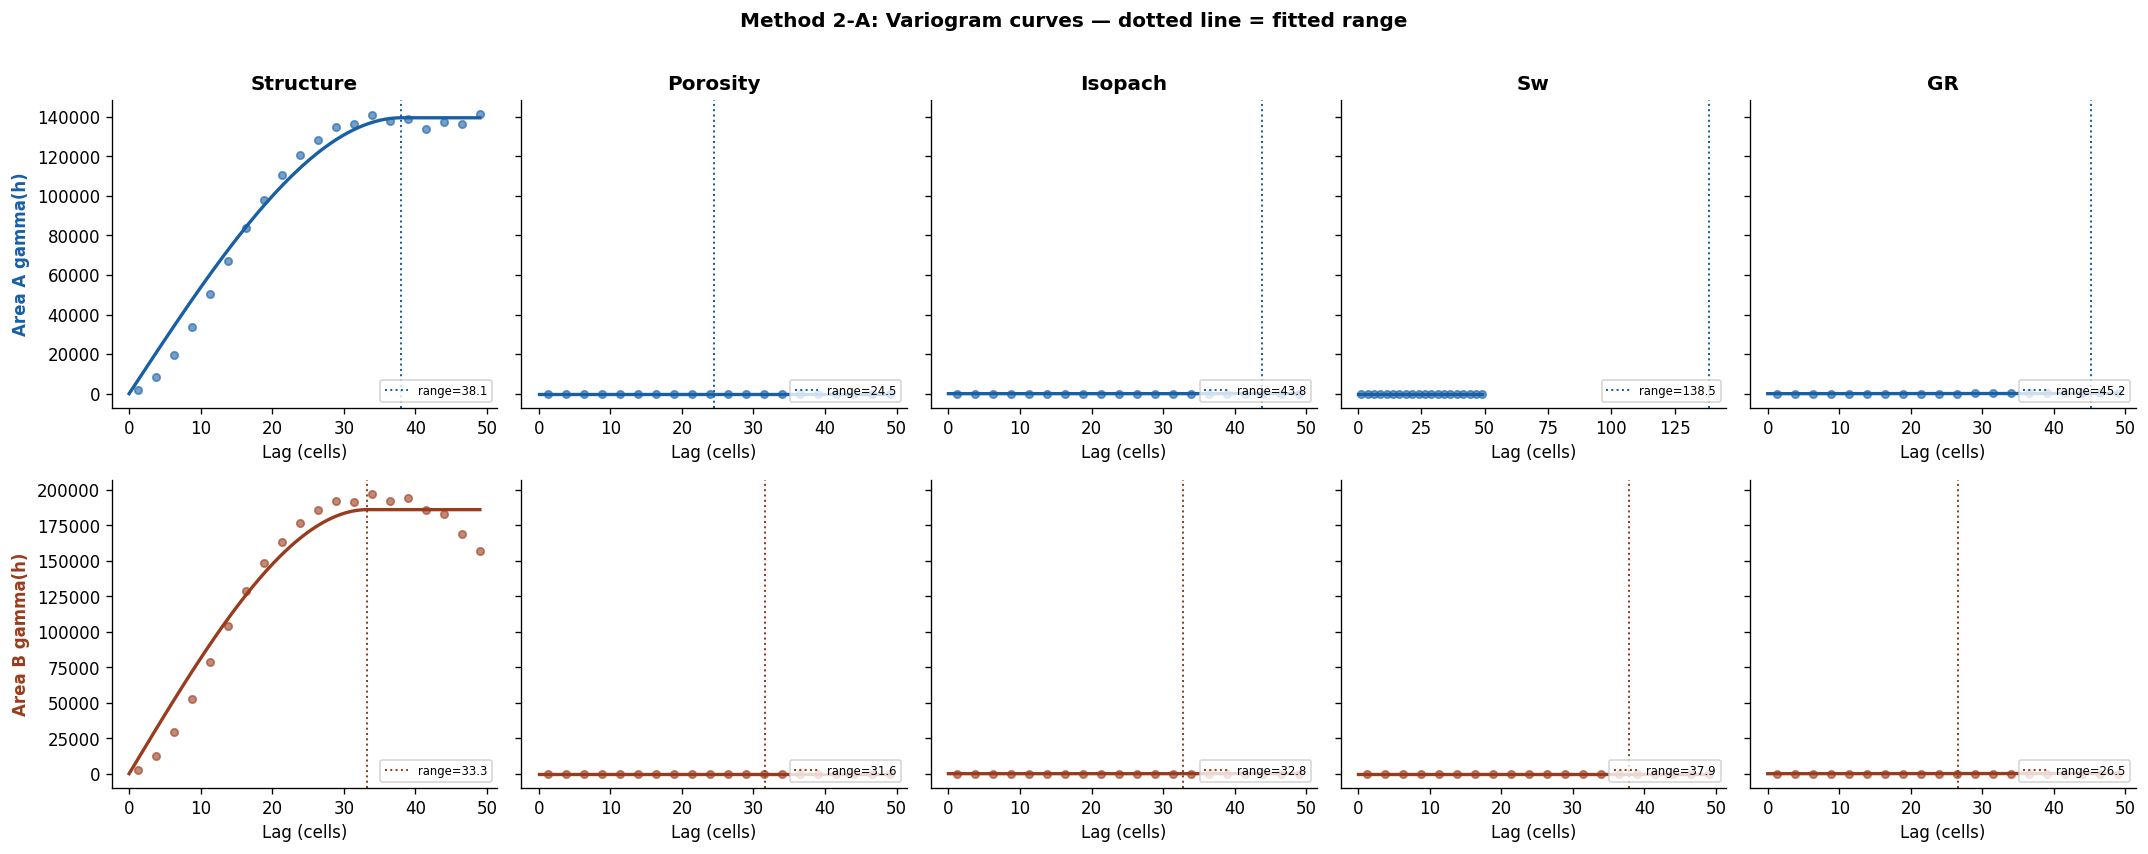

In [8]:
# ── Variogram curves side by side ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey="row")

for col, prop in enumerate(PROPS):
    for row, area in enumerate(AREAS):
        ax = axes[row, col]
        r  = vario_results[area][prop]
        h, gamma, valid = r["h"], r["gamma"], r["valid"]
        ax.scatter(h[valid], gamma[valid], s=20, color=COLORS[area], alpha=0.6, zorder=3)
        if r["fitted"]:
            hf = np.linspace(0, h[valid].max(), 200)
            ax.plot(hf, spherical(hf, *r["popt"]), color=COLORS[area], linewidth=2)
            ax.axvline(r["range"], color=COLORS[area], linestyle=":", linewidth=1.2,
                       label="range=" + str(round(r["range"], 1)))
            ax.legend(fontsize=7, loc="lower right")
        if row == 0: ax.set_title(prop, fontweight="bold")
        if col == 0: ax.set_ylabel(area + " gamma(h)", fontweight="bold", color=COLORS[area])
        ax.set_xlabel("Lag (cells)")

plt.suptitle("Method 2-A: Variogram curves — dotted line = fitted range",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("02a_variogram_curves.png", dpi=130, bbox_inches="tight")
plt.show()


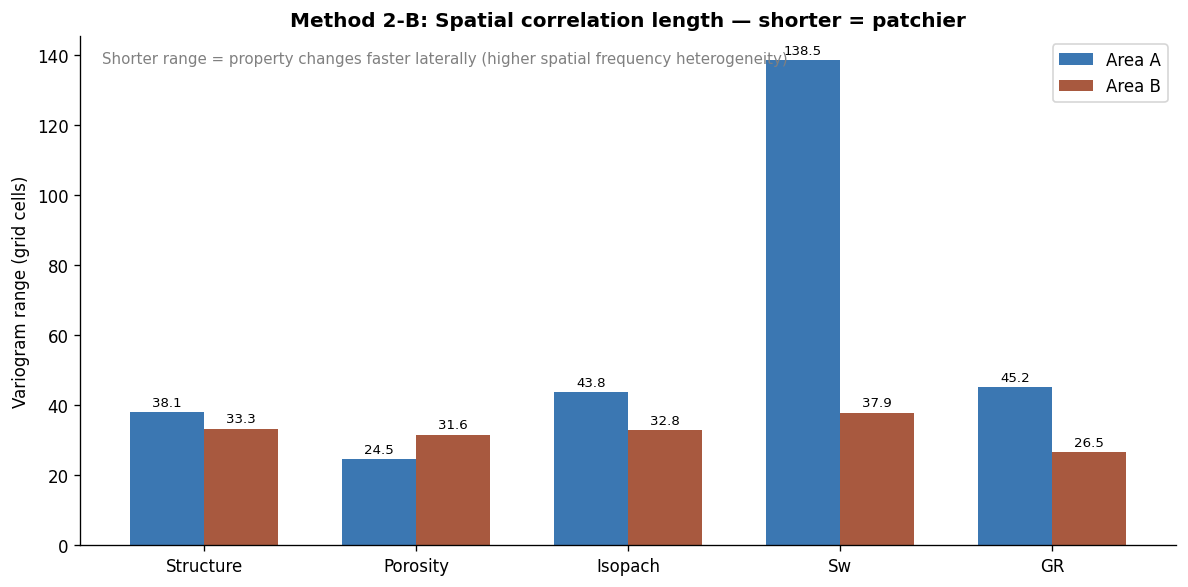

              Range A    Range B  Ratio B/A More continuous
Property                                                   
Structure   38.054263  33.290499       0.87          Area A
Porosity    24.511168  31.559869       1.29          Area B
Isopach     43.810466  32.809320       0.75          Area A
Sw         138.472618  37.886317       0.27          Area A
GR          45.244828  26.534130       0.59          Area A


In [9]:
# ── Range comparison bar chart ─────────────────────────────────────────────────
range_A = [vario_results["Area A"][p]["range"] for p in PROPS]
range_B = [vario_results["Area B"][p]["range"] for p in PROPS]

x_pos = np.arange(len(PROPS))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bA = ax.bar(x_pos-width/2, range_A, width, label="Area A",
            color=COLORS["Area A"], alpha=0.85)
bB = ax.bar(x_pos+width/2, range_B, width, label="Area B",
            color=COLORS["Area B"], alpha=0.85)
ax.bar_label(bA, fmt="%.1f", padding=2, fontsize=8)
ax.bar_label(bB, fmt="%.1f", padding=2, fontsize=8)
ax.set_xticks(x_pos); ax.set_xticklabels(PROPS)
ax.set_ylabel("Variogram range (grid cells)")
ax.set_title("Method 2-B: Spatial correlation length — shorter = patchier", fontweight="bold")
ax.legend()
ax.text(0.02, 0.97,
        "Shorter range = property changes faster laterally (higher spatial frequency heterogeneity)",
        transform=ax.transAxes, va="top", fontsize=9, color="gray")
plt.tight_layout()
plt.savefig("02b_range_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

range_df = pd.DataFrame({"Property": PROPS, "Range A": range_A, "Range B": range_B})
range_df["Ratio B/A"] = (range_df["Range B"]/range_df["Range A"]).round(2)
range_df["More continuous"] = range_df.apply(
    lambda r: "Area A" if r["Range A"] > r["Range B"] else "Area B", axis=1)
print(range_df.set_index("Property").to_string())


---
## Method 3 — PCA complexity index

We compare how many PCs are needed to explain 90% of the cumulative variance in each area.
Fewer PCs needed → properties co-vary more strongly → simpler, more correlated lateral structure.
More PCs needed → properties vary independently → geologically more complex area.


In [10]:
pca_results = {}
for area in AREAS:
    X = np.column_stack([grids[area][p].ravel() for p in PROPS])
    X_sc = StandardScaler().fit_transform(X)
    pca  = PCA(n_components=5)
    scores = pca.fit_transform(X_sc)
    pca_results[area] = dict(pca=pca, scores=scores, X_sc=X_sc)
    evr = pca.explained_variance_ratio_
    cumev = np.cumsum(evr)
    n90 = int(np.searchsorted(cumev, 0.90)) + 1
    print(f"{area}: explained variance = {np.round(evr*100,1)}")
    print(f"  PCs needed for 90% variance: {n90}")
    print(f"  Cumulative: {np.round(cumev*100,1)}")
    print()


Area A: explained variance = [90.5  6.9  2.1  0.4  0.1]
  PCs needed for 90% variance: 1
  Cumulative: [ 90.5  97.4  99.5  99.9 100. ]

Area B: explained variance = [75.5 11.9  5.1  4.8  2.7]
  PCs needed for 90% variance: 3
  Cumulative: [ 75.5  87.4  92.5  97.3 100. ]



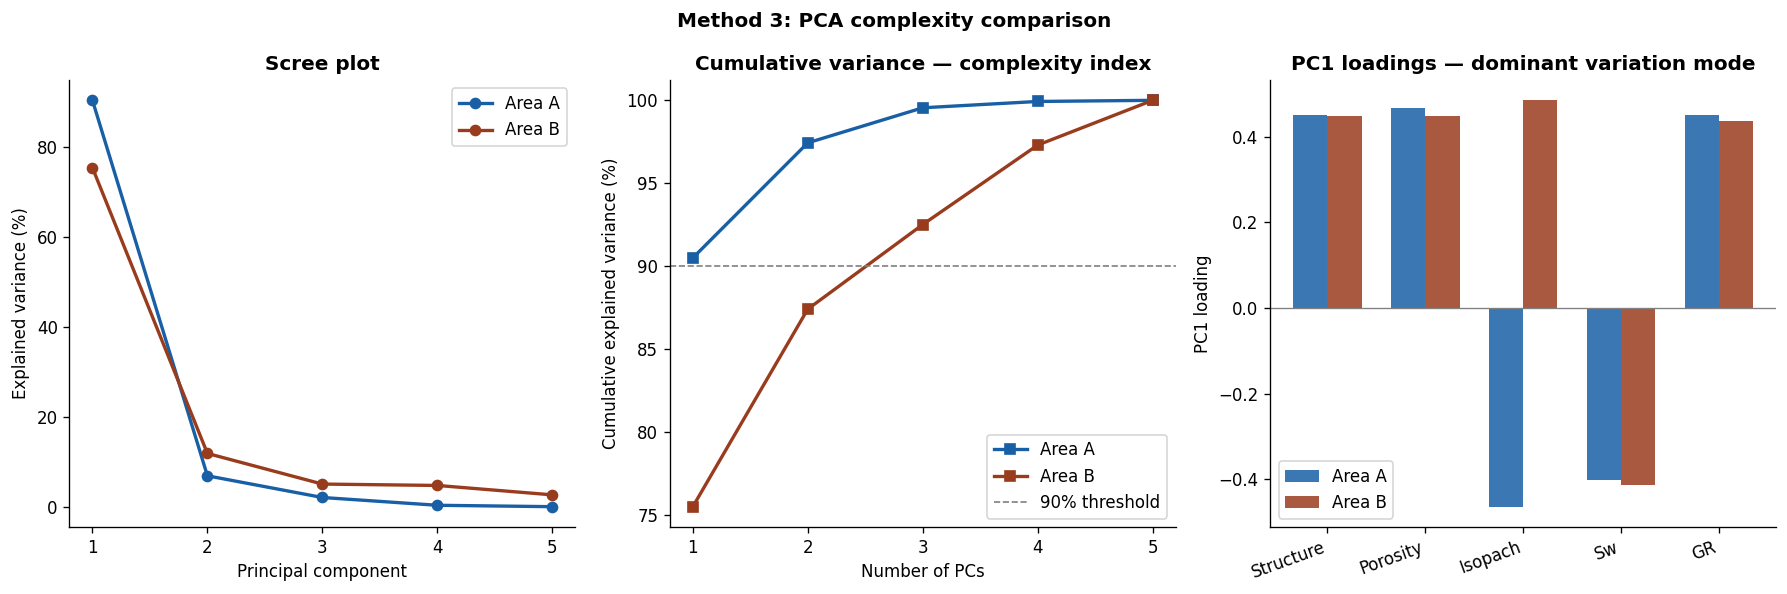

In [11]:
# ── Scree + cumulative variance ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scree
ax = axes[0]
for area in AREAS:
    ev = pca_results[area]['pca'].explained_variance_ratio_*100
    ax.plot(range(1,6), ev, 'o-', label=area, color=COLORS[area],
            linewidth=2, markersize=6)
ax.set_xlabel('Principal component')
ax.set_ylabel('Explained variance (%)')
ax.set_title('Scree plot', fontweight='bold')
ax.legend(); ax.set_xticks(range(1,6))

# Cumulative
ax2 = axes[1]
for area in AREAS:
    cumev = np.cumsum(pca_results[area]['pca'].explained_variance_ratio_)*100
    ax2.plot(range(1,6), cumev, 's-', label=area, color=COLORS[area],
             linewidth=2, markersize=6)
ax2.axhline(90, color='gray', linestyle='--', linewidth=1, label='90% threshold')
ax2.set_xlabel('Number of PCs')
ax2.set_ylabel('Cumulative explained variance (%)')
ax2.set_title('Cumulative variance — complexity index', fontweight='bold')
ax2.legend(); ax2.set_xticks(range(1,6))

# PC1 loadings comparison
ax3 = axes[2]
x_pos = np.arange(len(PROPS))
width = 0.35
for i, area in enumerate(AREAS):
    loads = pca_results[area]['pca'].components_[0]
    ax3.bar(x_pos + (i-0.5)*width, loads, width, label=area,
            color=COLORS[area], alpha=0.85)
ax3.axhline(0, color='gray', linewidth=0.8)
ax3.set_xticks(x_pos); ax3.set_xticklabels(PROPS, rotation=20, ha='right')
ax3.set_ylabel('PC1 loading')
ax3.set_title('PC1 loadings — dominant variation mode', fontweight='bold')
ax3.legend()

plt.suptitle('Method 3: PCA complexity comparison', fontweight='bold')
plt.tight_layout()
plt.savefig('03a_pca_complexity.png', dpi=130, bbox_inches='tight')
plt.show()


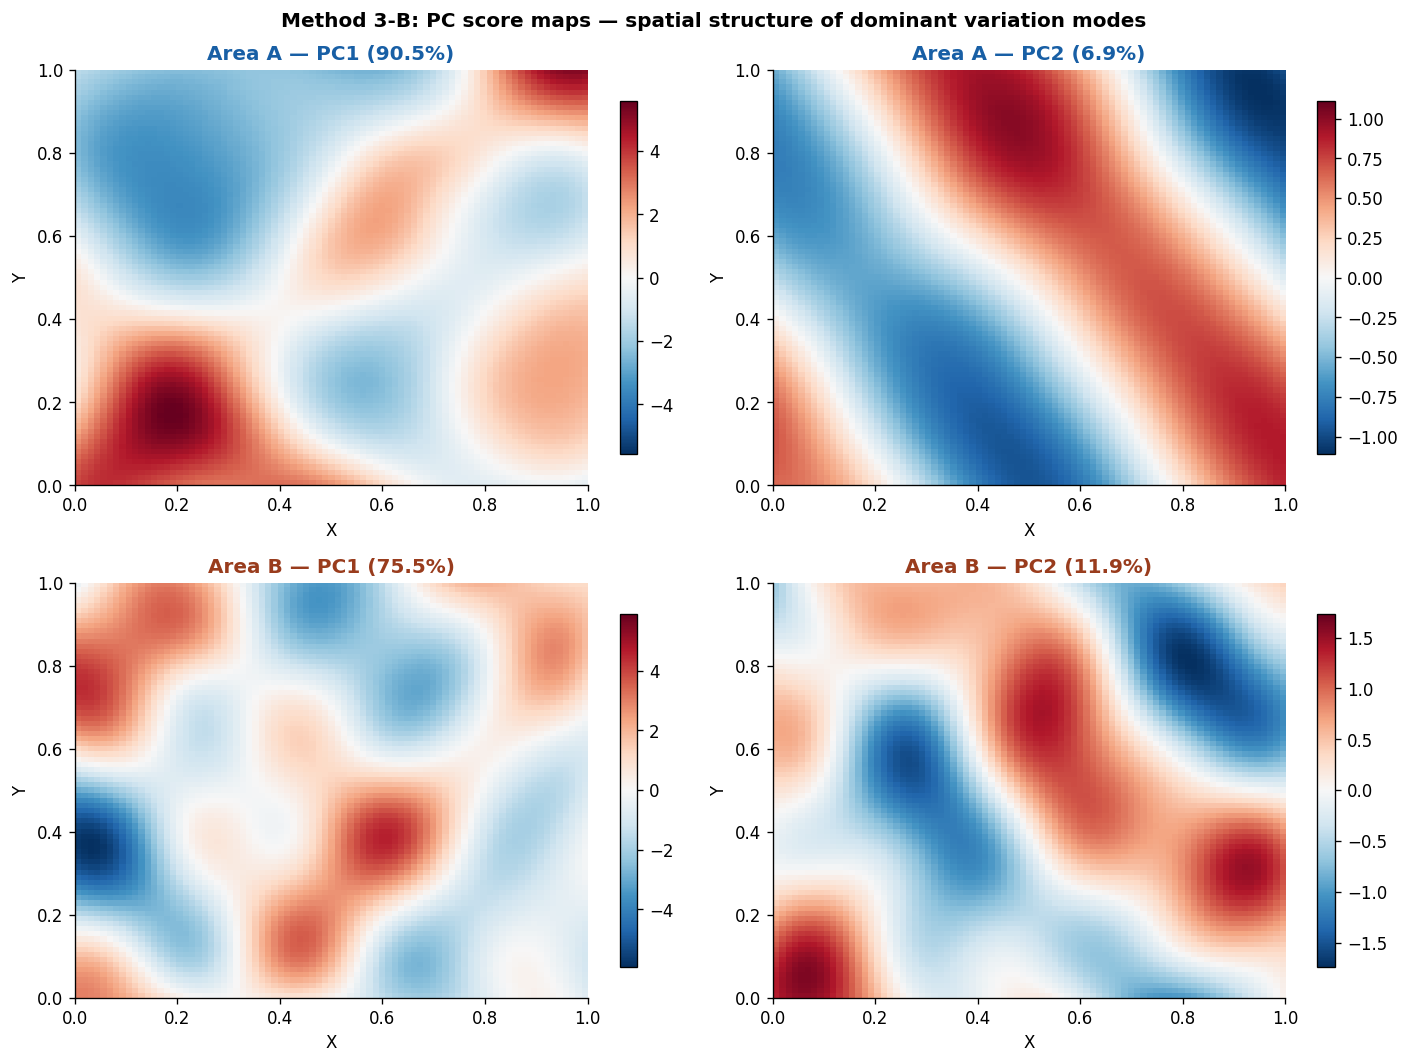

In [12]:
# ── PC score maps (PC1 and PC2) side by side ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
pc_labels = ['PC1', 'PC2']

for row, area in enumerate(AREAS):
    scores = pca_results[area]['scores']
    for col, pc_idx in enumerate([0, 1]):
        ax = axes[row, col]
        pc_map = scores[:, pc_idx].reshape(GRID+1, GRID+1)
        vmax = np.abs(pc_map).max()
        im = ax.imshow(pc_map, origin='lower', cmap='RdBu_r',
                       vmin=-vmax, vmax=vmax, extent=[0,1,0,1], aspect='auto')
        plt.colorbar(im, ax=ax, shrink=0.85)
        evr = pca_results[area]['pca'].explained_variance_ratio_[pc_idx]*100
        ax.set_title(f'{area} — {pc_labels[col]} ({evr:.1f}%)', fontweight='bold',
                     color=COLORS[area])
        ax.set_xlabel('X'); ax.set_ylabel('Y')

plt.suptitle('Method 3-B: PC score maps — spatial structure of dominant variation modes',
             fontweight='bold')
plt.tight_layout()
plt.savefig('03b_pc_score_maps.png', dpi=130, bbox_inches='tight')
plt.show()


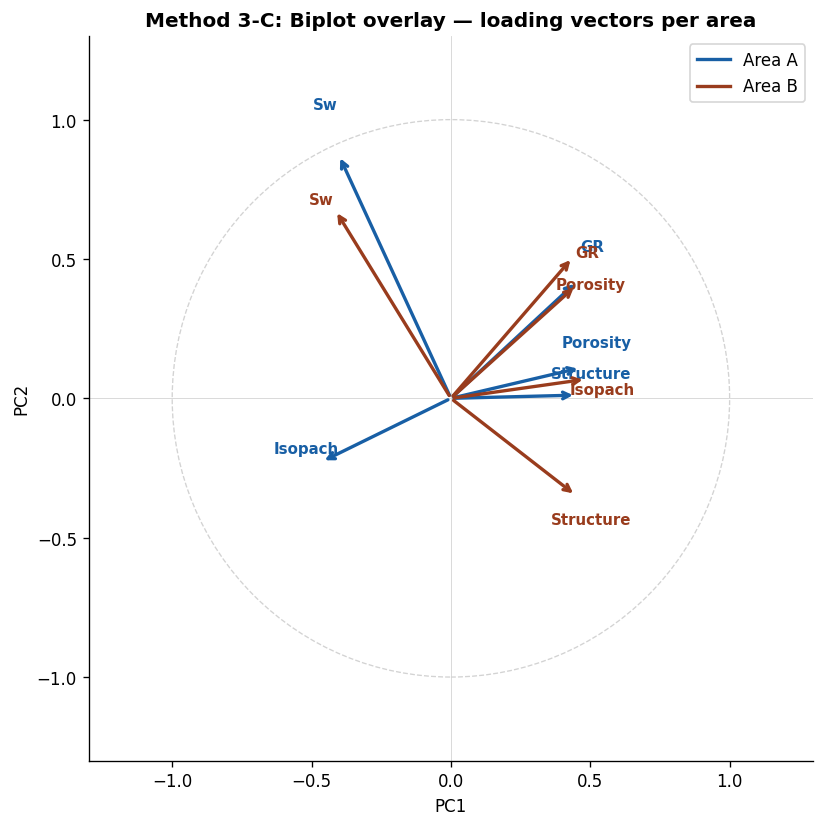

In [13]:
# ── Biplot overlay (PC1 vs PC2 loadings, both areas) ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
circle = plt.Circle((0,0), 1, fill=False, color='lightgray', linestyle='--', linewidth=0.8)
ax.add_patch(circle)
ax.axhline(0, color='lightgray', linewidth=0.5)
ax.axvline(0, color='lightgray', linewidth=0.5)

for area in AREAS:
    loads = pca_results[area]['pca'].components_
    for i, prop in enumerate(PROPS):
        ax.annotate('', xy=(loads[0,i], loads[1,i]), xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color=COLORS[area], lw=2))
        offset = 0.06 if area == 'Area A' else -0.06
        ax.text(loads[0,i]*1.12, loads[1,i]*1.12 + offset,
                f'{prop}', fontsize=9, ha='center', color=COLORS[area], fontweight='bold')

for area in AREAS:
    ax.plot([], [], color=COLORS[area], linewidth=2, label=area)
ax.legend(loc='upper right')
ax.set_xlim(-1.3,1.3); ax.set_ylim(-1.3,1.3)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Method 3-C: Biplot overlay — loading vectors per area', fontweight='bold')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('03c_biplot_overlay.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Method 4 — Spatial cross-variogram (co-variogram)

γ₁₂(h) = ½ · E[(Z₁(x)−Z₁(x+h))(Z₂(x)−Z₂(x+h))]

A negative cross-variogram at short lags between Porosity and Sw indicates that where one is high,
the other is low — which is the expected physical relationship. Comparing this between areas reveals
whether the capillary pressure regime and property co-variation structure differs spatially.


In [14]:
def cross_variogram(g1, g2, n_lags=15, max_lag_frac=0.4, n_sample=1500):
    """Compute cross-variogram between two co-located grids."""
    f1, f2 = g1.ravel(), g2.ravel()
    rng  = np.random.default_rng(0)
    idx  = rng.choice(len(f1), size=min(n_sample, len(f1)), replace=False)
    r_i, c_i = np.unravel_index(idx, g1.shape)
    coords = np.stack([r_i, c_i], axis=1).astype(float)
    v1, v2 = f1[idx], f2[idx]
    dists  = squareform(pdist(coords))
    max_d  = dists.max() * max_lag_frac
    lags   = np.linspace(0, max_d, n_lags+1)
    xgamma = []
    for lo, hi in zip(lags[:-1], lags[1:]):
        mask = (dists > lo) & (dists <= hi)
        if mask.sum() < 5:
            xgamma.append(np.nan); continue
        ii, jj = np.where(mask)
        xgamma.append(0.5*np.mean((v1[ii]-v1[jj])*(v2[ii]-v2[jj])))
    centers = (lags[:-1]+lags[1:])/2
    return centers, np.array(xgamma)

# Key pairs of geological interest
pairs = [
    ('Porosity', 'Sw',  'Porosity–Sw'),
    ('Porosity', 'GR',  'Porosity–GR'),
    ('Structure','Sw',  'Structure–Sw'),
    ('Isopach',  'GR',  'Isopach–GR'),
    ('Porosity', 'Isopach', 'Porosity–Isopach'),
]

xvario = {}
for area in AREAS:
    xvario[area] = {}
    for p1, p2, label in pairs:
        h, xg = cross_variogram(grids[area][p1], grids[area][p2])
        xvario[area][label] = (h, xg)
    print(f"{area}: cross-variograms computed for {len(pairs)} pairs")


Area A: cross-variograms computed for 5 pairs
Area B: cross-variograms computed for 5 pairs


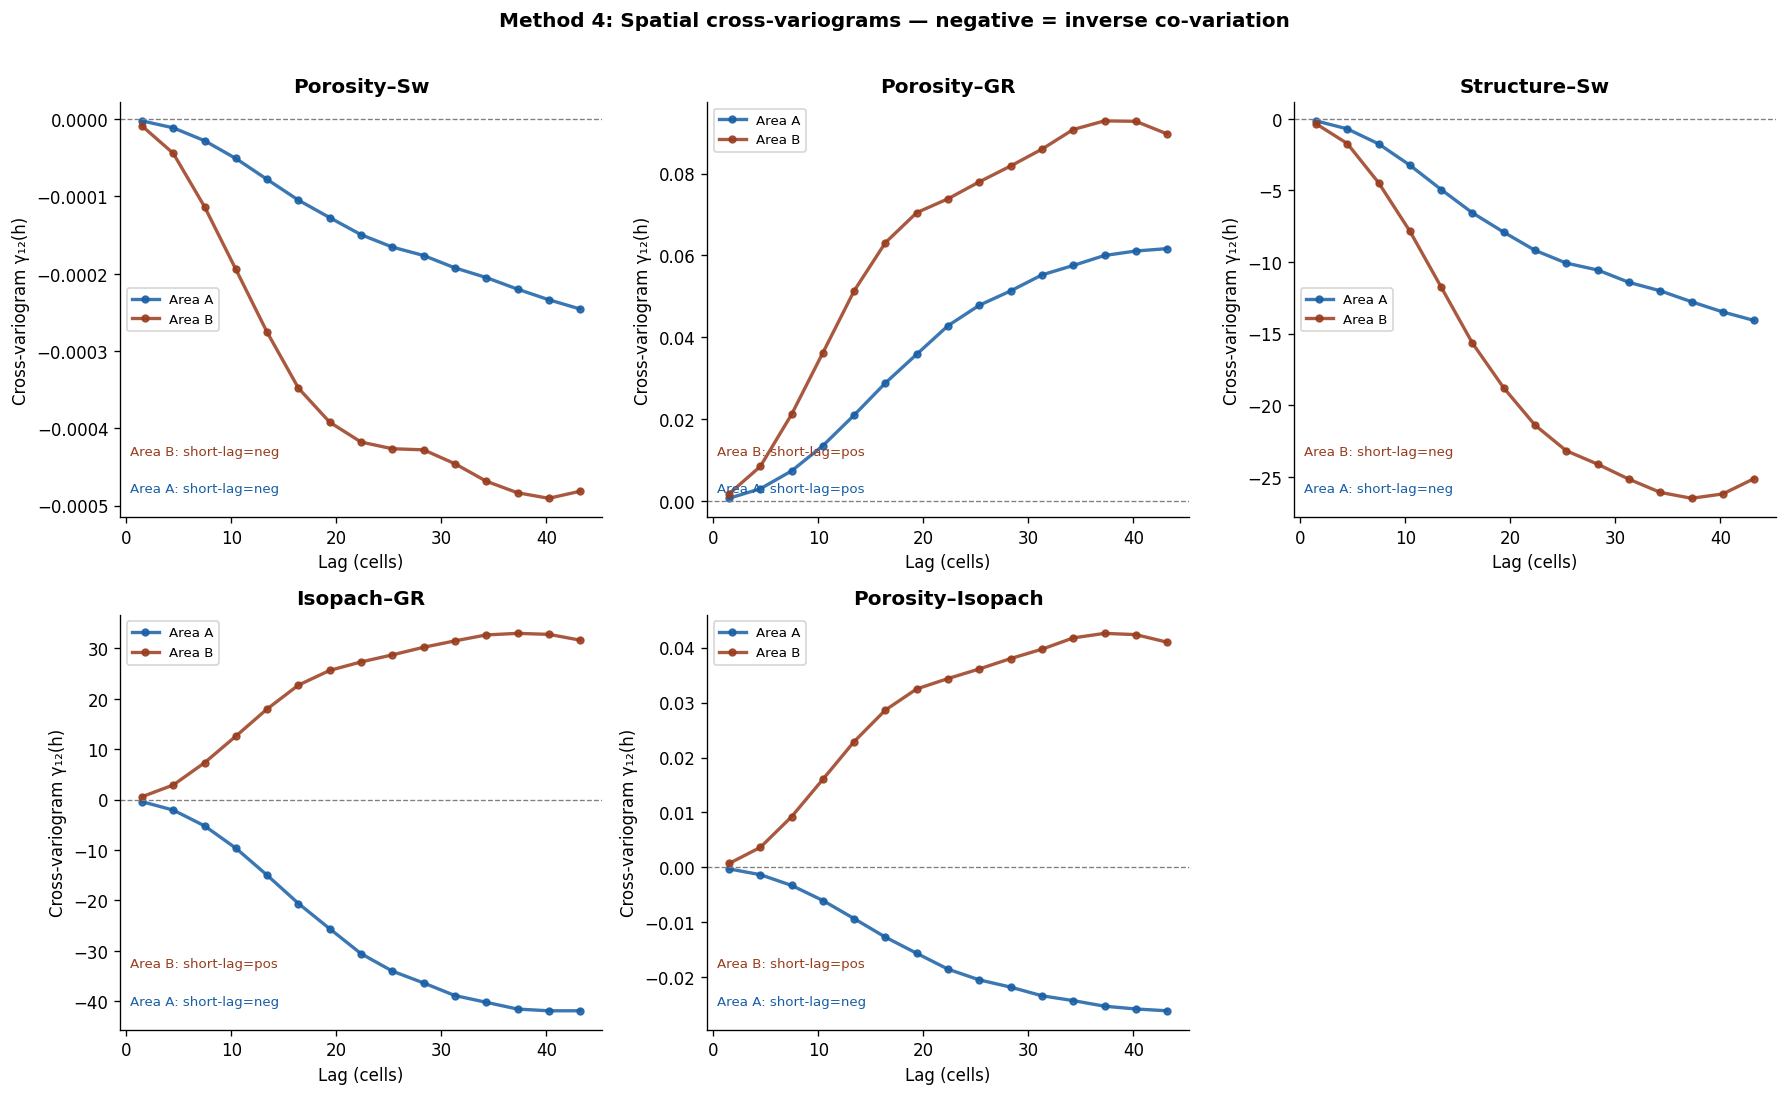

In [15]:
# ── Cross-variogram comparison plots ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (p1, p2, label) in enumerate(pairs):
    ax = axes[idx]
    for area in AREAS:
        h, xg = xvario[area][label]
        valid = ~np.isnan(xg)
        ax.plot(h[valid], xg[valid], 'o-', label=area, color=COLORS[area],
                linewidth=2, markersize=4, alpha=0.85)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Lag (cells)'); ax.set_ylabel('Cross-variogram γ₁₂(h)')
    ax.legend(fontsize=8)
    # Annotate the sign at short lag
    for area in AREAS:
        h, xg = xvario[area][label]
        valid = ~np.isnan(xg)
        if valid.any():
            sign = 'neg' if xg[valid][0] < 0 else 'pos'
            ax.text(0.02, 0.06 if area=='Area A' else 0.15,
                    f'{area}: short-lag={sign}', transform=ax.transAxes,
                    fontsize=8, color=COLORS[area])

axes[-1].set_visible(False)
plt.suptitle('Method 4: Spatial cross-variograms — negative = inverse co-variation',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_cross_variograms.png', dpi=130, bbox_inches='tight')
plt.show()


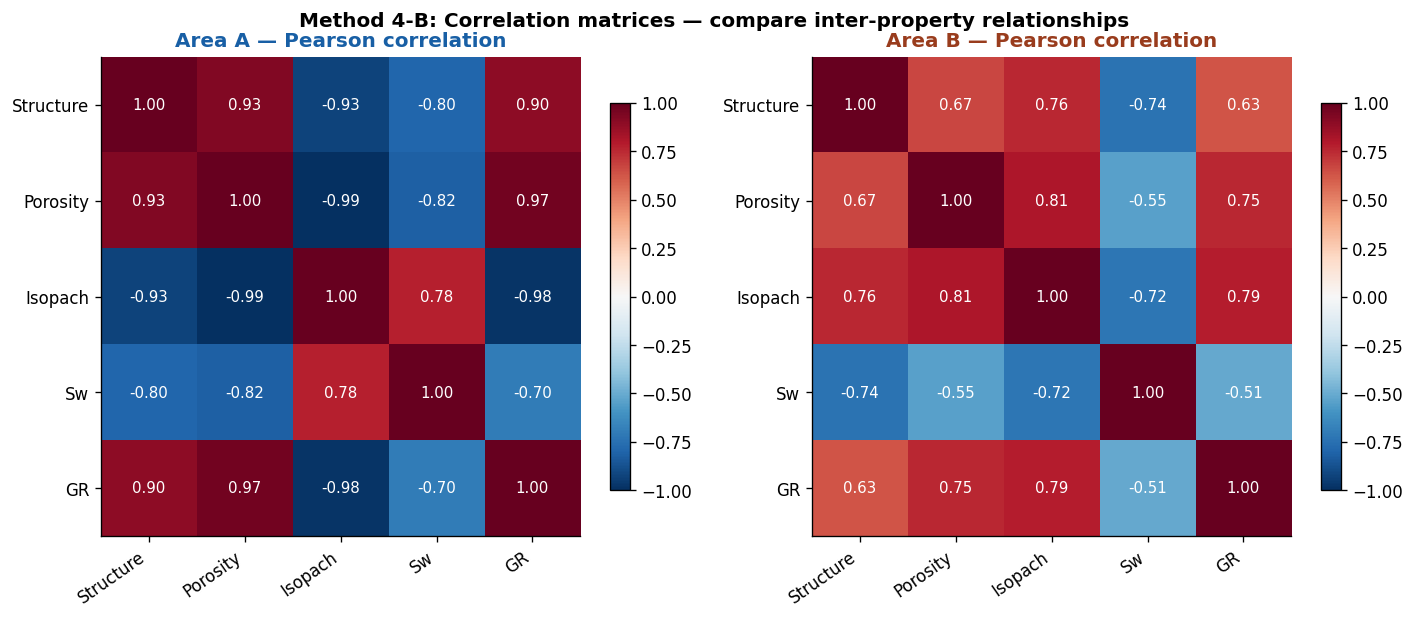

In [16]:
# ── Cross-correlation matrix heatmaps side-by-side ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, area in zip(axes, AREAS):
    df = pd.DataFrame({p: grids[area][p].ravel() for p in PROPS})
    corr = df.corr()
    im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(5)); ax.set_xticklabels(PROPS, rotation=35, ha='right')
    ax.set_yticks(range(5)); ax.set_yticklabels(PROPS)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                    fontsize=9, color='white' if abs(corr.values[i,j])>0.5 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'{area} — Pearson correlation', fontweight='bold', color=COLORS[area])

plt.suptitle('Method 4-B: Correlation matrices — compare inter-property relationships',
             fontweight='bold')
plt.tight_layout()
plt.savefig('04b_correlation_matrices.png', dpi=130, bbox_inches='tight')
plt.show()


---
## Method 5 — Information entropy maps

Shannon entropy H = −Σ pᵢ log(pᵢ) computed within a moving spatial window quantifies
local unpredictability. High entropy = rapid property variation = high geological uncertainty.

We compare:
- Global entropy per property per area (single number)
- Spatial entropy maps (where is uncertainty concentrated?)
- Entropy ratio maps (which area is riskier where?)


In [17]:
def local_entropy(grid, window=9, n_bins=10):
    """Compute Shannon entropy in a sliding window via raster scanning."""
    rows, cols = grid.shape
    ent = np.zeros_like(grid, dtype=float)
    half = window // 2
    g_min, g_max = grid.min(), grid.max()
    bins = np.linspace(g_min, g_max, n_bins+1)
    for r in range(rows):
        for c in range(cols):
            r0,r1 = max(0,r-half), min(rows,r+half+1)
            c0,c1 = max(0,c-half), min(cols,c+half+1)
            patch = grid[r0:r1, c0:c1].ravel()
            counts, _ = np.histogram(patch, bins=bins)
            counts = counts[counts > 0]
            p = counts / counts.sum()
            ent[r,c] = -np.sum(p*np.log(p+1e-12))
    return ent

print("Computing entropy maps (may take ~30 s)...")
entropy_maps = {}
for area in AREAS:
    entropy_maps[area] = {}
    for prop in PROPS:
        entropy_maps[area][prop] = local_entropy(grids[area][prop], window=9)
        print(f"  {area} / {prop} done")
print("Done.")


Computing entropy maps (may take ~30 s)...
  Area A / Structure done
  Area A / Porosity done
  Area A / Isopach done
  Area A / Sw done
  Area A / GR done
  Area B / Structure done
  Area B / Porosity done
  Area B / Isopach done
  Area B / Sw done
  Area B / GR done
Done.


Mean spatial entropy (higher = more unpredictable):
        Structure  Porosity  Isopach      Sw      GR
Area                                                
Area A     0.7397    0.8071   0.8632  0.7459  0.8379
Area B     1.0242    0.9100   0.8926  0.8957  0.9330


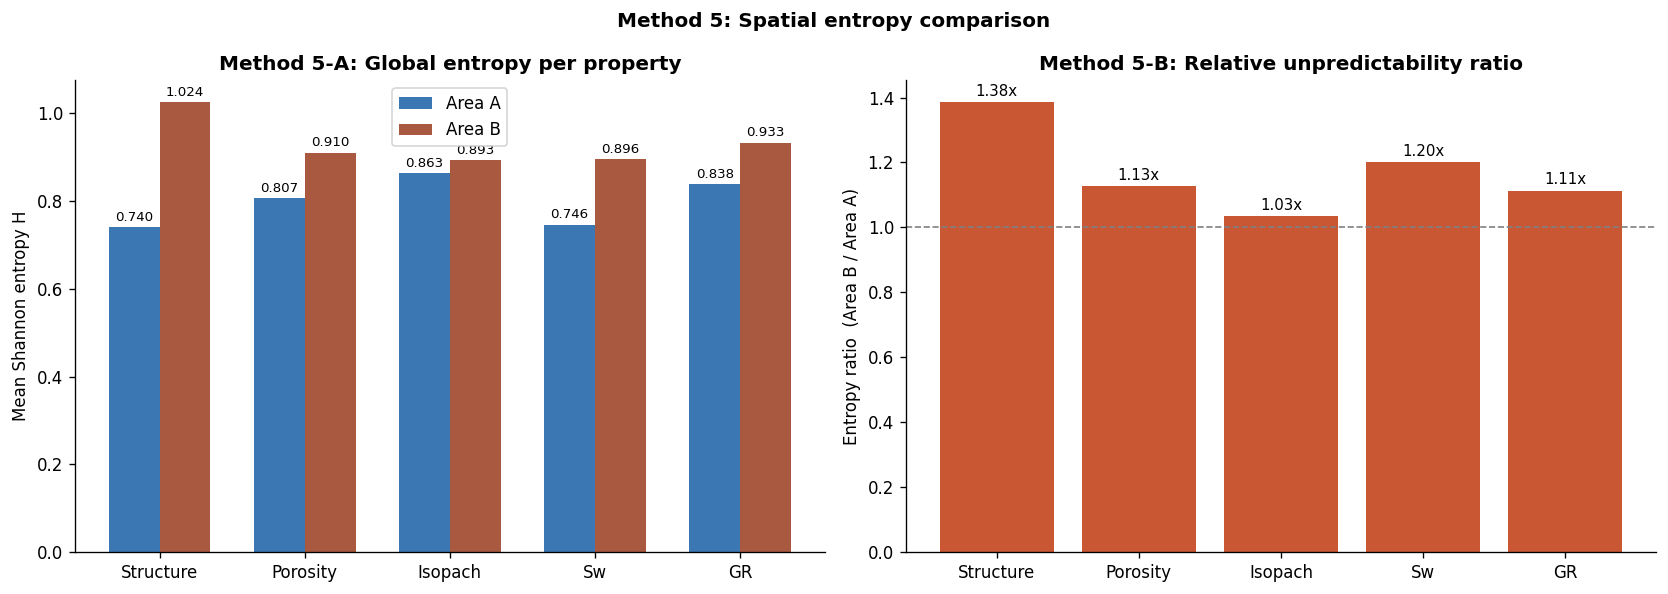

In [18]:
# ── Global entropy summary ────────────────────────────────────────────────────
ent_summary = {}
for area in AREAS:
    ent_summary[area] = {p: entropy_maps[area][p].mean() for p in PROPS}

ent_df = pd.DataFrame(ent_summary).T
ent_df.index.name = 'Area'
print("Mean spatial entropy (higher = more unpredictable):")
print(ent_df.round(4).to_string())

x_pos = np.arange(len(PROPS))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bA = ax.bar(x_pos-width/2, ent_df.loc['Area A'], width, label='Area A',
            color=COLORS['Area A'], alpha=0.85)
bB = ax.bar(x_pos+width/2, ent_df.loc['Area B'], width, label='Area B',
            color=COLORS['Area B'], alpha=0.85)
ax.bar_label(bA, fmt='%.3f', padding=2, fontsize=8)
ax.bar_label(bB, fmt='%.3f', padding=2, fontsize=8)
ax.set_xticks(x_pos); ax.set_xticklabels(PROPS)
ax.set_ylabel('Mean Shannon entropy H')
ax.set_title('Method 5-A: Global entropy per property', fontweight='bold')
ax.legend()

ax2 = axes[1]
ratio = ent_df.loc['Area B'] / ent_df.loc['Area A']
col_r = ['#c03a10' if r > 1 else '#185FA5' for r in ratio]
bars  = ax2.bar(PROPS, ratio, color=col_r, alpha=0.85)
ax2.bar_label(bars, fmt='%.2fx', padding=2, fontsize=9)
ax2.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Entropy ratio  (Area B / Area A)')
ax2.set_title('Method 5-B: Relative unpredictability ratio', fontweight='bold')

plt.suptitle('Method 5: Spatial entropy comparison', fontweight='bold')
plt.tight_layout()
plt.savefig('05a_entropy_summary.png', dpi=130, bbox_inches='tight')
plt.show()


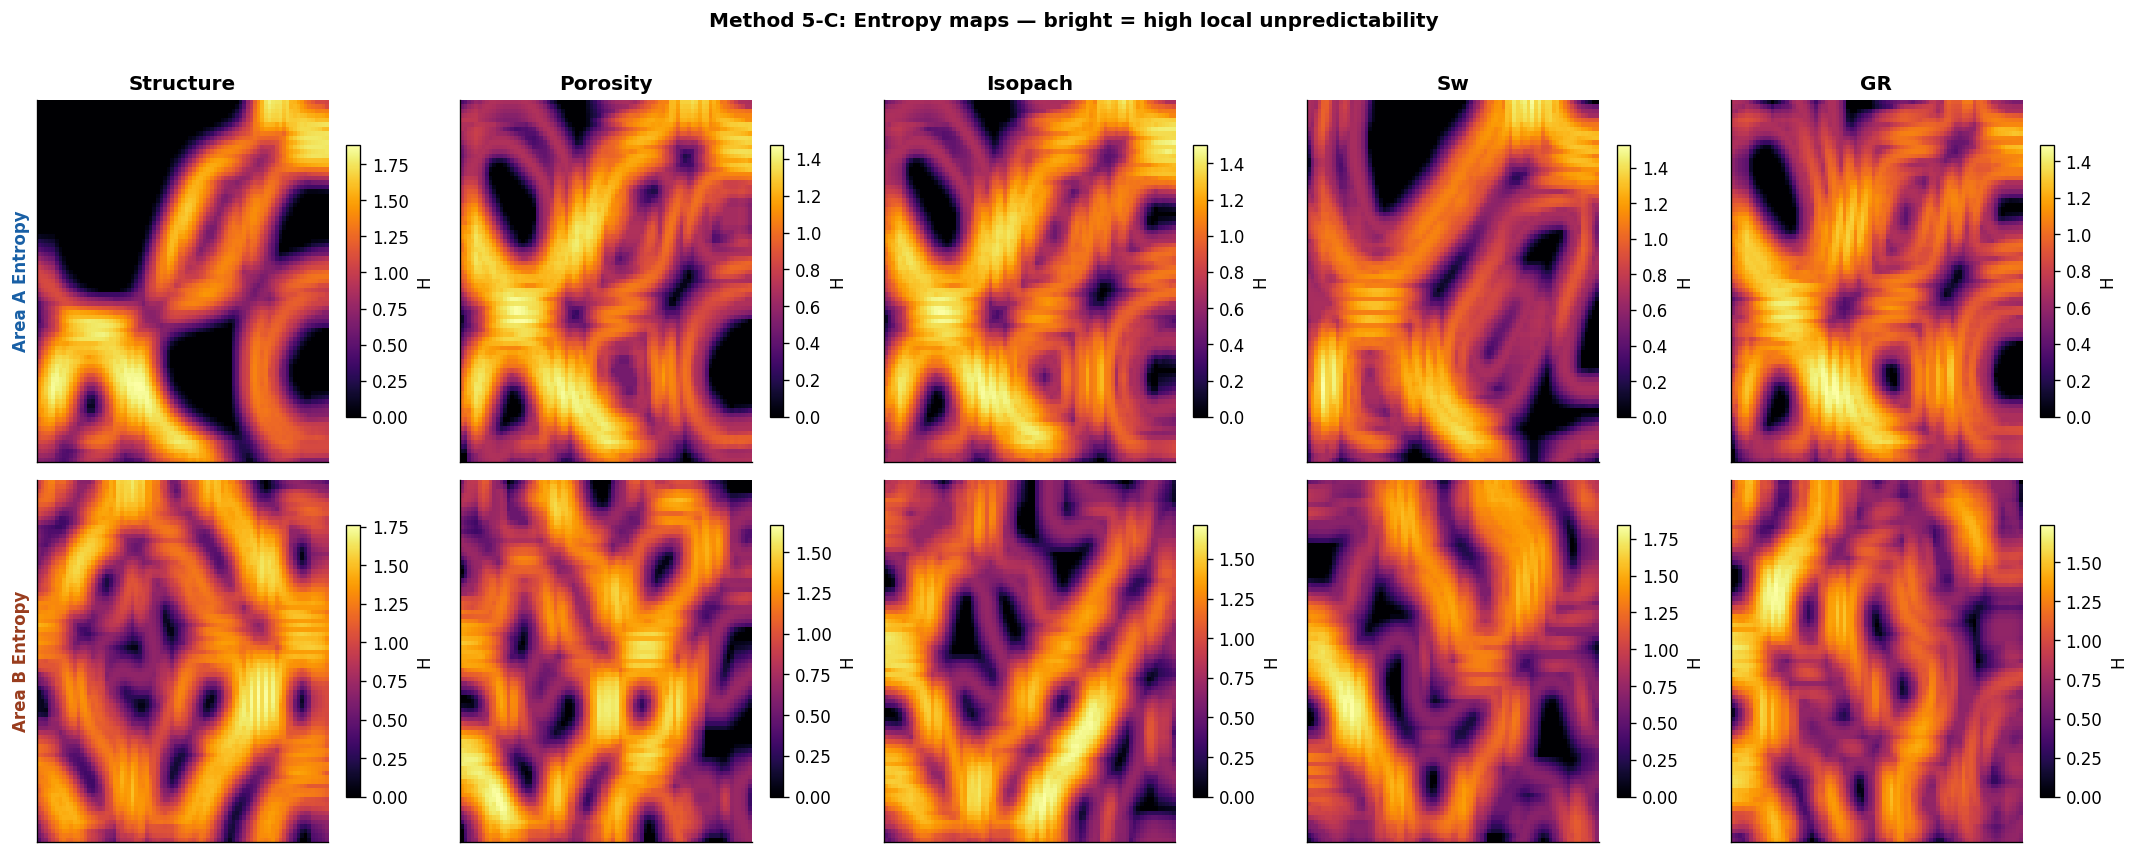

In [19]:
# ── Spatial entropy maps ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for row, area in enumerate(AREAS):
    for col, prop in enumerate(PROPS):
        ax = axes[row, col]
        em = entropy_maps[area][prop]
        im = ax.imshow(em, origin="lower", cmap="inferno",
                       extent=[0,1,0,1], aspect="auto")
        plt.colorbar(im, ax=ax, shrink=0.75, label="H")
        if row == 0: ax.set_title(prop, fontweight="bold")
        if col == 0: ax.set_ylabel(area + " Entropy", fontweight="bold", color=COLORS[area])
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Method 5-C: Entropy maps — bright = high local unpredictability",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("05c_entropy_maps.png", dpi=130, bbox_inches="tight")
plt.show()


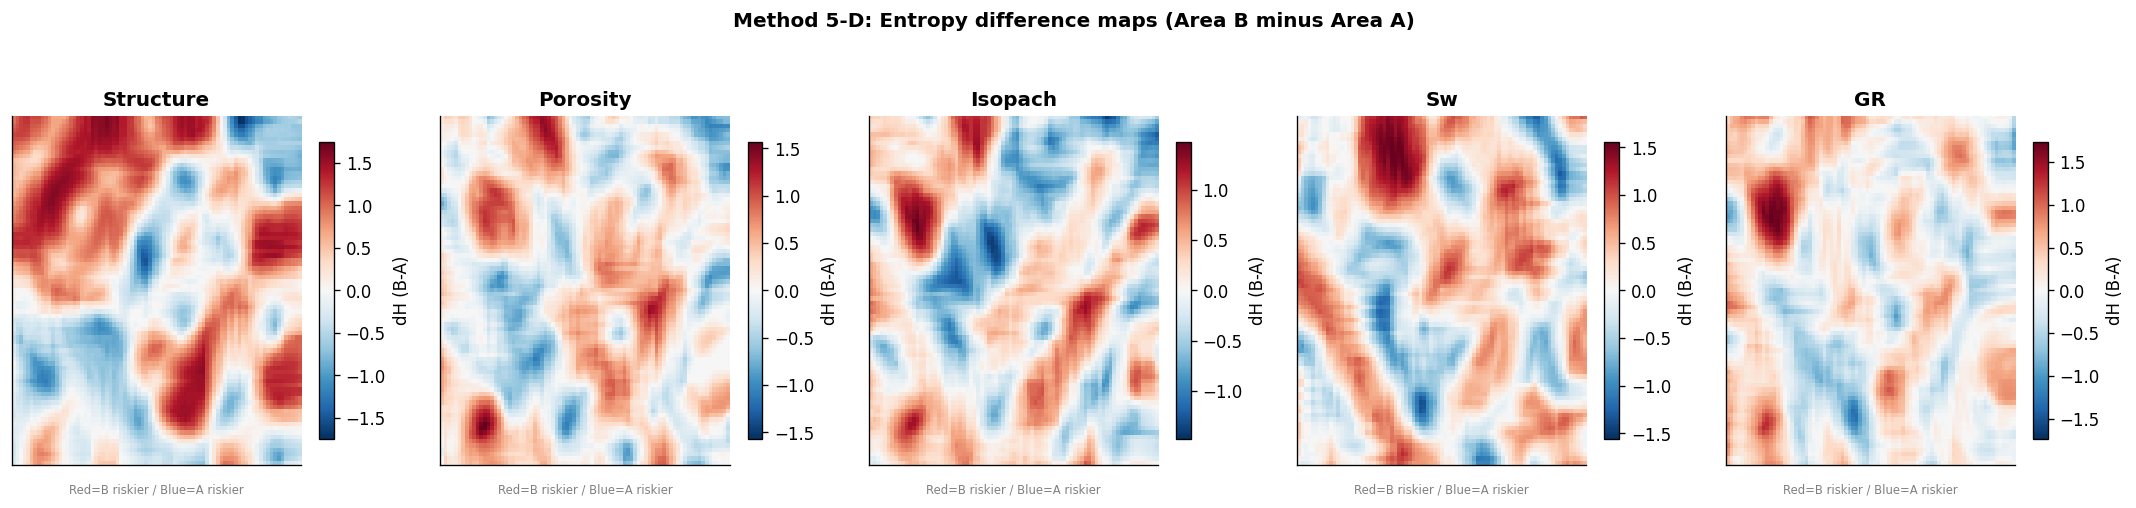

In [20]:
# ── Entropy difference maps (B minus A, normalized) ──────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for col, prop in enumerate(PROPS):
    ax = axes[col]
    diff = entropy_maps["Area B"][prop] - entropy_maps["Area A"][prop]
    vmax = np.abs(diff).max()
    im = ax.imshow(diff, origin="lower", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax, extent=[0,1,0,1], aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.85, label="dH (B-A)")
    ax.set_title(prop, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, -0.08, "Red=B riskier / Blue=A riskier",
            transform=ax.transAxes, ha="center", fontsize=7, color="gray")

plt.suptitle("Method 5-D: Entropy difference maps (Area B minus Area A)",
             fontsize=12, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig("05d_entropy_difference.png", dpi=130, bbox_inches="tight")
plt.show()


---
## Summary — integrated comparison dashboard

A single view consolidating all five comparison metrics into one scorecard.


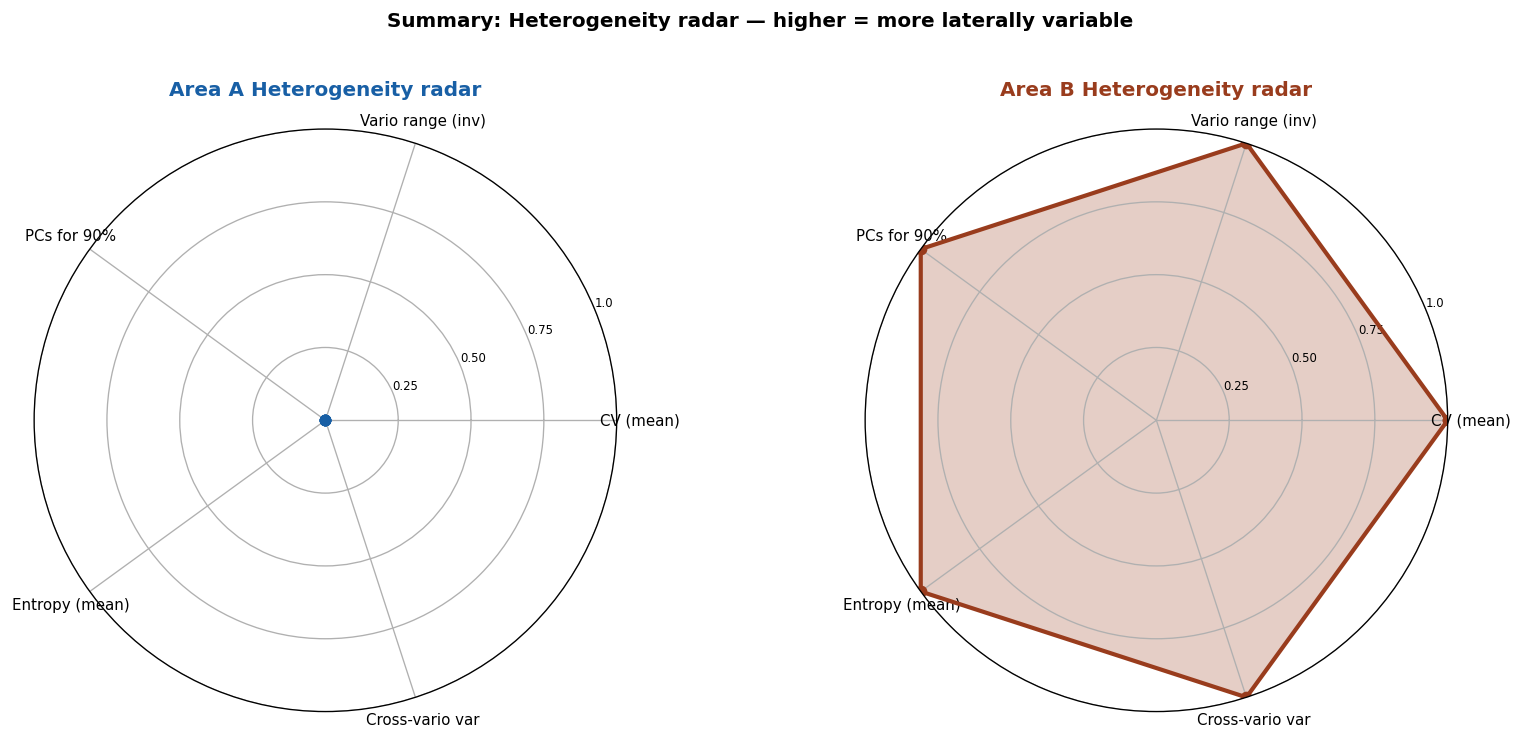

In [21]:
# ── Radar chart: Area A vs Area B across all metrics ──────────────────────────
metrics = ["CV (mean)", "Vario range (inv)", "PCs for 90%", "Entropy (mean)", "Cross-vario var"]

def norm01(a, b):
    mx = max(a, b); mn = min(a, b)
    if mx == mn: return 0.5, 0.5
    return (a-mn)/(mx-mn), (b-mn)/(mx-mn)

cv_mean_A = cv_df.loc["Area A"].mean()
cv_mean_B = cv_df.loc["Area B"].mean()
m1_A, m1_B = norm01(cv_mean_A, cv_mean_B)

rng_mean_A = np.nanmean([vario_results["Area A"][p]["range"] for p in PROPS])
rng_mean_B = np.nanmean([vario_results["Area B"][p]["range"] for p in PROPS])
m2_A, m2_B = norm01(1/rng_mean_A, 1/rng_mean_B)

def n90(area):
    cumev = np.cumsum(pca_results[area]["pca"].explained_variance_ratio_)
    return int(np.searchsorted(cumev, 0.90)) + 1
n90_A, n90_B = n90("Area A"), n90("Area B")
m3_A, m3_B = norm01(n90_A, n90_B)

ent_A = np.mean(list(ent_summary["Area A"].values()))
ent_B = np.mean(list(ent_summary["Area B"].values()))
m4_A, m4_B = norm01(ent_A, ent_B)

def xv_var(area):
    vals = []
    for _, label in [(p[0], p[2]) for p in pairs]:
        h, xg = xvario[area][label]
        valid = ~np.isnan(xg)
        if valid.any(): vals.extend(xg[valid].tolist())
    return np.var(vals)
xv_A, xv_B = xv_var("Area A"), xv_var("Area B")
m5_A, m5_B = norm01(xv_A, xv_B)

scores_A = [m1_A, m2_A, m3_A, m4_A, m5_A]
scores_B = [m1_B, m2_B, m3_B, m4_B, m5_B]

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))

for ax, (area, scores) in zip(axes, [("Area A", scores_A), ("Area B", scores_B)]):
    vals = scores + scores[:1]
    ax.plot(angles, vals, "o-", linewidth=2.5, color=COLORS[area])
    ax.fill(angles, vals, alpha=0.25, color=COLORS[area])
    ax.set_thetagrids(np.degrees(angles[:-1]), metrics, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25","0.50","0.75","1.0"], fontsize=7)
    ax.set_title(area + " Heterogeneity radar", fontweight="bold", color=COLORS[area], pad=20)

plt.suptitle("Summary: Heterogeneity radar — higher = more laterally variable",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("06a_radar_summary.png", dpi=130, bbox_inches="tight")
plt.show()


In [22]:
# ── Final scorecard table ─────────────────────────────────────────────────────
scorecard = pd.DataFrame({
    'Metric': metrics,
    'Area A (raw)': [round(cv_mean_A,4), round(rng_mean_A,1), n90_A,
                     round(ent_A,4), round(xv_A,6)],
    'Area B (raw)': [round(cv_mean_B,4), round(rng_mean_B,1), n90_B,
                     round(ent_B,4), round(xv_B,6)],
    'Area A (norm)': [round(s,3) for s in scores_A],
    'Area B (norm)': [round(s,3) for s in scores_B],
    'More heterogeneous': [
        'A' if s_a > s_b else 'B'
        for s_a, s_b in zip(scores_A, scores_B)
    ]
}).set_index('Metric')

print("=" * 70)
print("INTEGRATED COMPARISON SCORECARD")
print("=" * 70)
print(scorecard.to_string())
print()
total_A = sum(scores_A); total_B = sum(scores_B)
winner = 'Area A' if total_A > total_B else 'Area B'
print(f"Overall heterogeneity score  ->  Area A: {total_A:.2f}  |  Area B: {total_B:.2f}")
print(f"=> {winner} is laterally MORE heterogeneous across all five methods.")


INTEGRATED COMPARISON SCORECARD
                   Area A (raw)  Area B (raw)  Area A (norm)  Area B (norm) More heterogeneous
Metric                                                                                        
CV (mean)              0.098300      0.114100            0.0            1.0                  B
Vario range (inv)     58.000000     32.400000            0.0            1.0                  B
PCs for 90%            1.000000      3.000000            0.0            1.0                  B
Entropy (mean)         0.798700      0.931100            0.0            1.0                  B
Cross-vario var      148.273212    200.972038            0.0            1.0                  B

Overall heterogeneity score  ->  Area A: 0.00  |  Area B: 5.00
=> Area B is laterally MORE heterogeneous across all five methods.


---
## Interpretation guide

| Score | Geological meaning |
|-------|-------------------|
| High CV ratio | Greater property spread — wider facies or diagenetic overprint range |
| Short variogram range | Property changes over shorter distances — patchy reservoir, more faulting, or higher-freq stratigraphy |
| More PCs needed for 90% | Properties vary independently — multiple controlling processes at work |
| Higher cross-variogram variance | Inter-property relationships change with distance — fluid contacts or diagenesis overprinting depositional signal |
| Higher entropy | Local unpredictability — requires denser well control for reliable interpolation |

A consistently higher-scoring area across all five metrics is the geologically more complex target and
carries greater volumetric uncertainty. Well spacing, geostatistical simulation resolution, and seismic
attribute integration should all be calibrated to the dominant heterogeneity scale identified by the
variogram range of the most critical reservoir property (typically porosity or isopach).
